
# UMAP on MNIST (via `sklearn.datasets.fetch_openml`)

This notebook:
- Downloads **MNIST** from OpenML using `sklearn.datasets.fetch_openml` (70,000 images, 784 features).
- Runs **UMAP** (`umap-learn` implementation) to get a 2D embedding.
- Plots the embedding colored by digit label.
- Demonstrates **out-of-sample** embedding via `umap.UMAP.transform` on a held-out split.

> Requirements: `scikit-learn`, `umap-learn`, `matplotlib`, `numpy`.


In [2]:

# If umap-learn is not installed, uncomment the next line to install.
# %pip install umap-learn


In [7]:

SEED = 42
SUBSAMPLE = 10000   # set to None for full 70k (will be slower)
N_NEIGHBORS = 15
MIN_DIST = 0.1
N_COMPONENTS = 2    # 2D embedding
TEST_FRACTION = 0.2 # for out-of-sample transform demo


In [8]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import umap.umap_ as umap

np.random.seed(SEED)


In [9]:

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
print("Full dataset:", X.shape, y.shape)


Full dataset: (70000, 784) (70000,)


In [10]:

if SUBSAMPLE is not None and SUBSAMPLE < X.shape[0]:
    idx = np.random.choice(X.shape[0], SUBSAMPLE, replace=False)
    X = X[idx]
    y = y[idx]
print("Using:", X.shape, y.shape)


Using: (10000, 784) (10000,)


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (8000, 784)  Test: (2000, 784)


In [12]:
%%time
umap_model = umap.UMAP(
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    n_components=N_COMPONENTS,
    random_state=SEED+5,
    metric='euclidean'
)
Z_train = umap_model.fit_transform(X_train)
print("Embedding shape (train):", Z_train.shape)


/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape (train): (8000, 2)
CPU times: user 18 s, sys: 1.08 s, total: 19 s
Wall time: 16.1 s


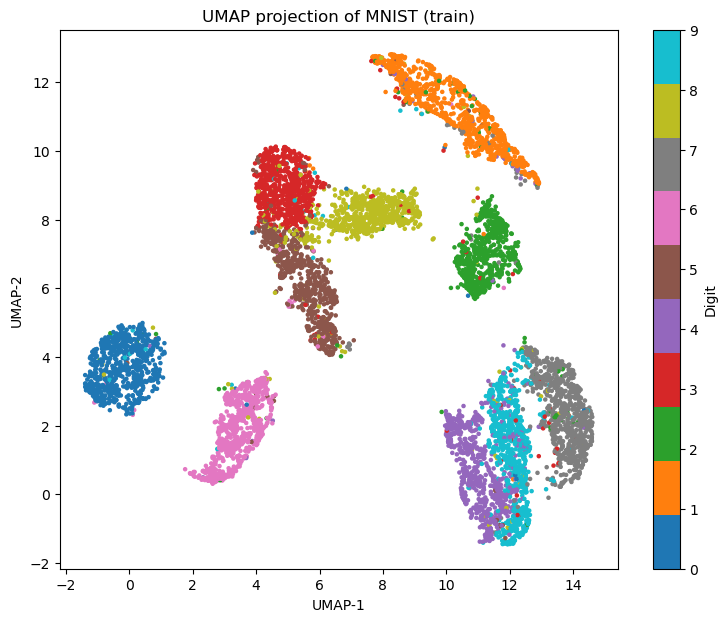

In [13]:

plt.figure(figsize=(9,7))
sc = plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, cmap="tab10")
plt.title("UMAP projection of MNIST (train)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit")
plt.show()


In [14]:

Z_test = umap_model.transform(X_test)
print("Embedding shape (test):", Z_test.shape)


Embedding shape (test): (2000, 2)


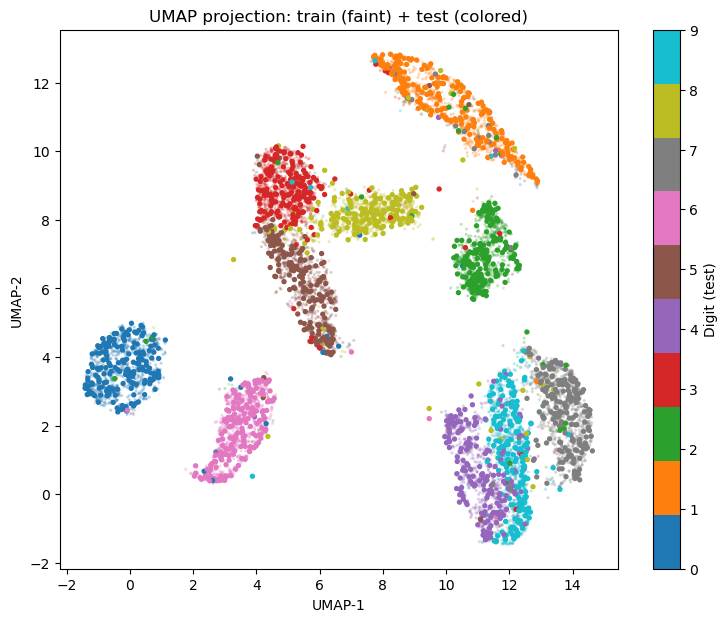

In [15]:

plt.figure(figsize=(9,7))
plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=2, alpha=0.2, cmap="tab10")
sc = plt.scatter(Z_test[:,0], Z_test[:,1], c=y_test, s=8, cmap="tab10")
plt.title("UMAP projection: train (faint) + test (colored)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit (test)")
plt.show()



## Notes & Tips
- Use PCA (e.g. 50 dims) before UMAP for speed.
- Try different metrics (`cosine`, `manhattan`) for variety.
- Use `umap_model.transform(new_data)` for out-of-sample points.


In [18]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Select a small subset for clarity (e.g., 200 points)
N_SHOW = 200
idx_show = np.random.choice(X_train.shape[0], N_SHOW, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('UMAP scatter with digit images')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

for i in idx_show:
    xy = Z_train[i]
    img = X_train[i].reshape(28, 28)
    imagebox = OffsetImage(img, cmap='gray', zoom=2.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)

plt.show()

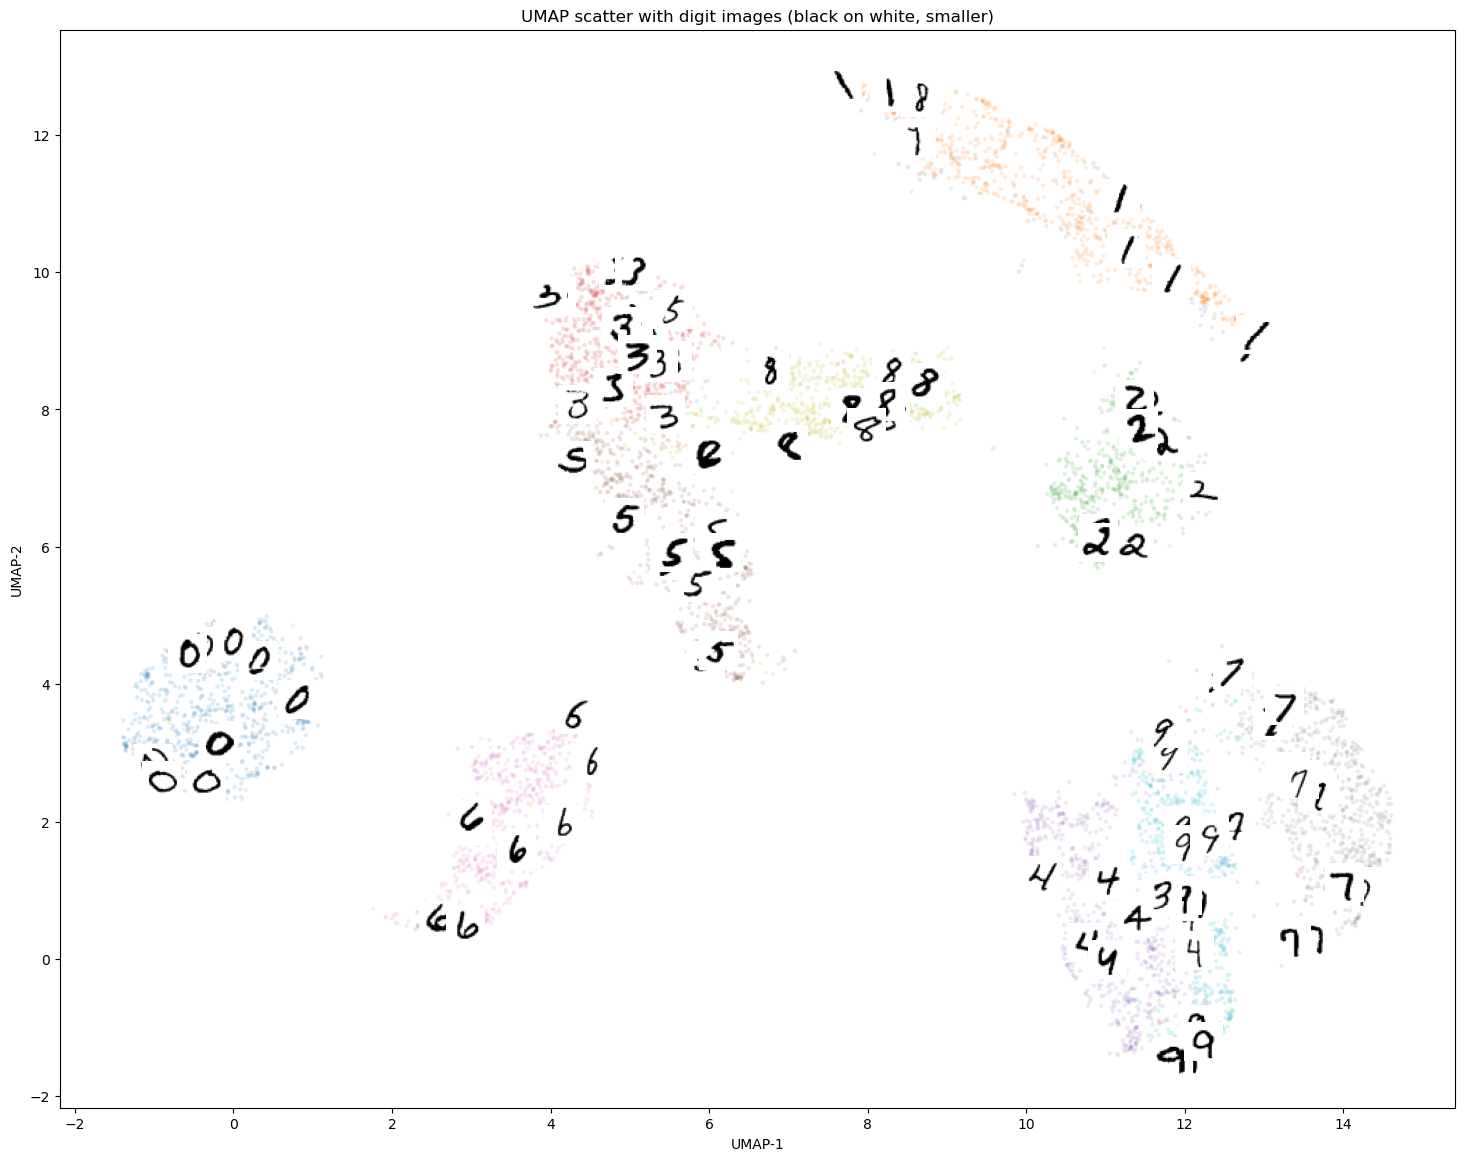

In [29]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

N_SHOW = 100
idx_show = np.random.choice(X_train.shape[0], N_SHOW, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with digit images (black on white, smaller)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Overlay a faint scatter for reference
ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.1, cmap='tab10')

for i in idx_show:
    xy = Z_train[i]
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img  # Reverse polarity: black digits on white background
    imagebox = OffsetImage(img, cmap='gray', zoom=1.0)  # Smaller images
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)

ax.update_datalim(Z_train[idx_show])
ax.autoscale_view()
plt.show()

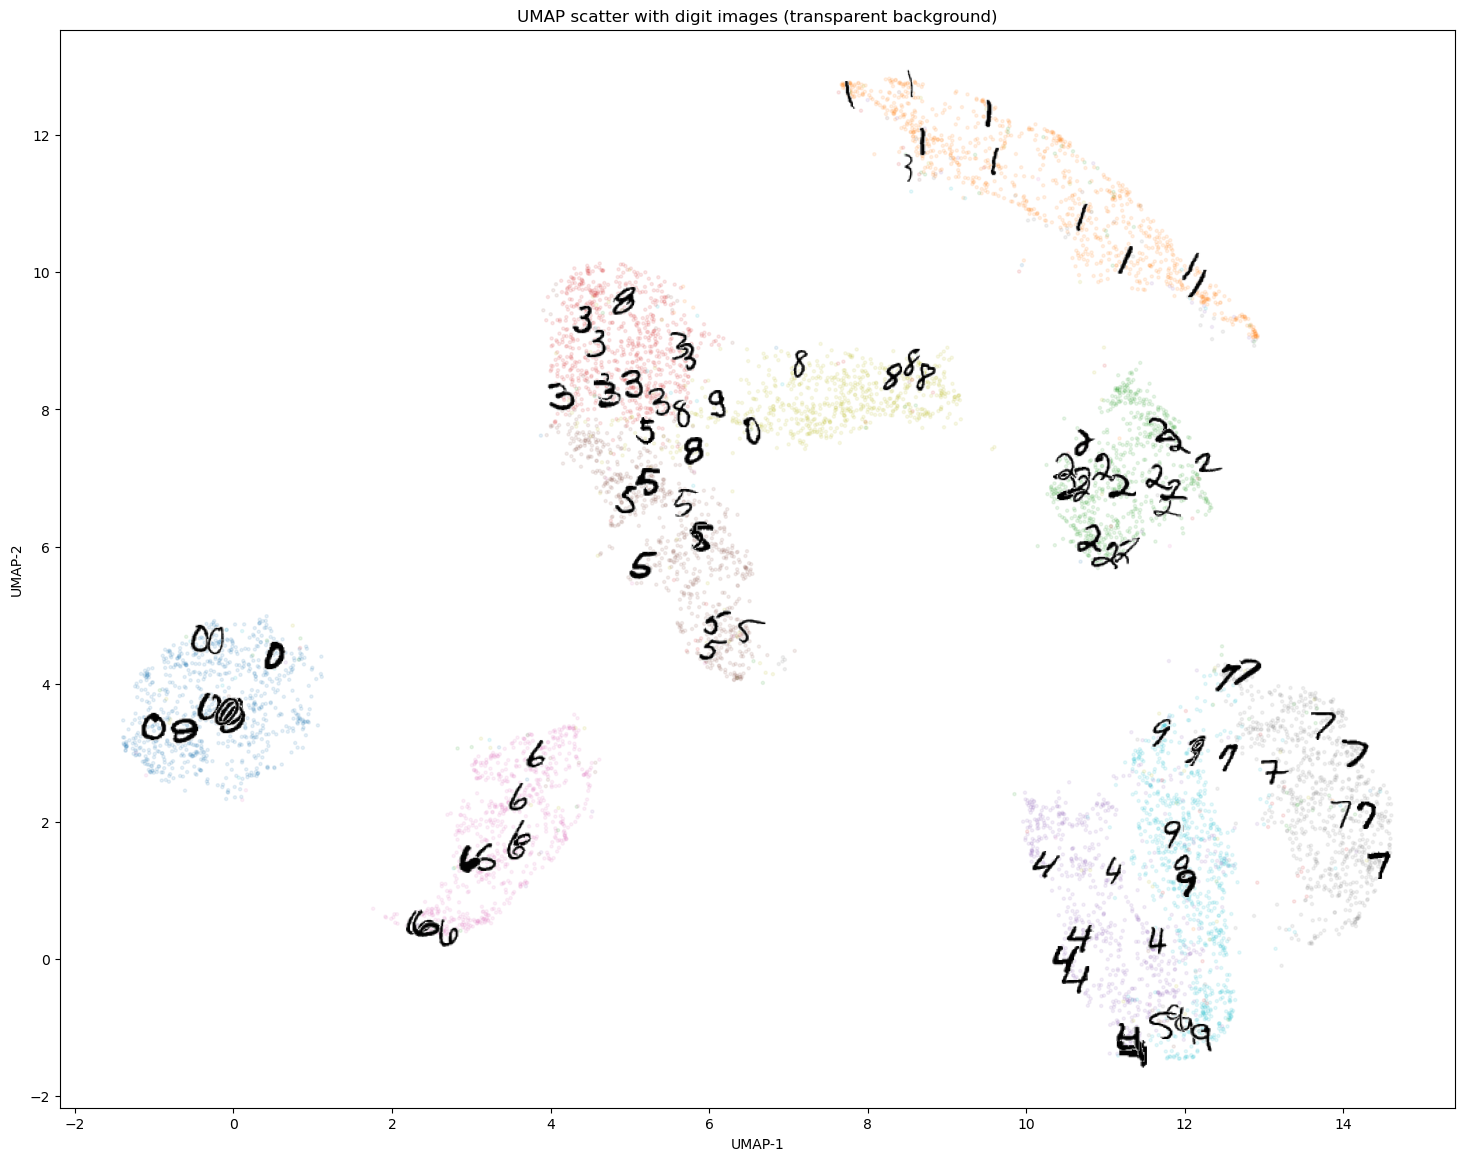

In [30]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

N_SHOW = 100
idx_show = np.random.choice(X_train.shape[0], N_SHOW, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with digit images (transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Overlay a faint scatter for reference
ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.1, cmap='tab10')

for i in idx_show:
    xy = Z_train[i]
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img  # Reverse polarity: black digits
    # Make background transparent: set pixels near white to alpha=0
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img  # R
    rgba_img[..., 1] = img  # G
    rgba_img[..., 2] = img  # B
    # Alpha channel: 0 if pixel is near white, else 1
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)

ax.update_datalim(Z_train[idx_show])
ax.autoscale_view()
plt.show()

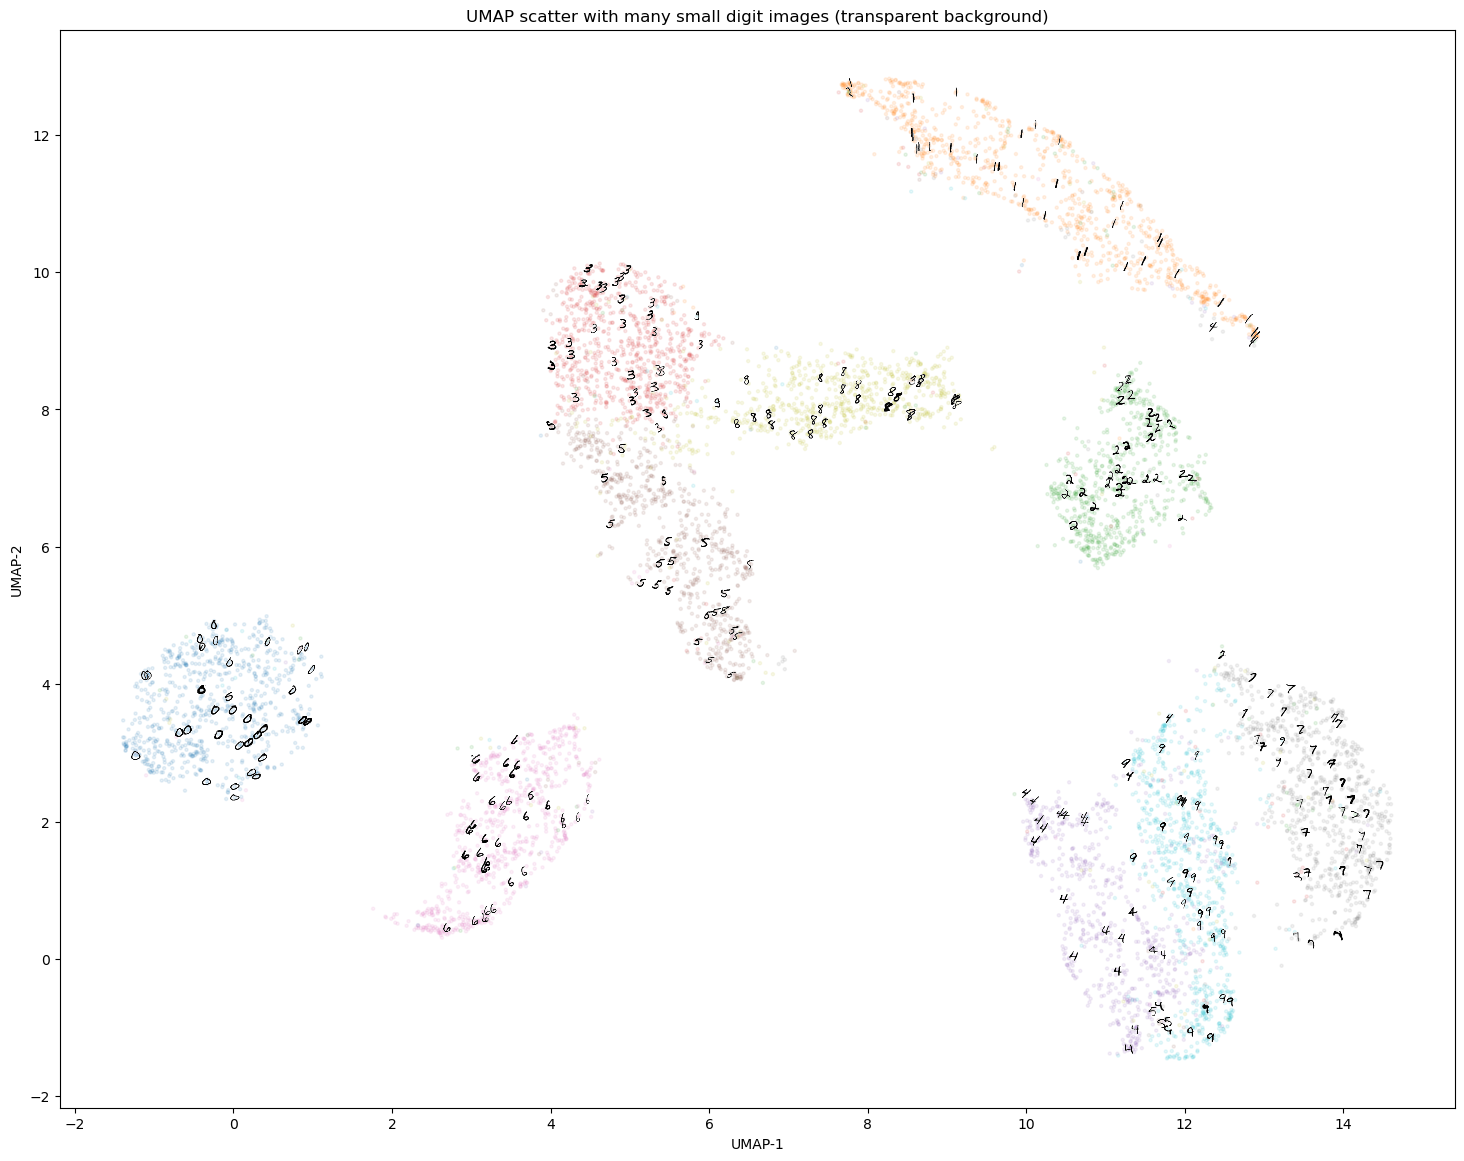

In [31]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

N_SHOW = 300
idx_show = np.random.choice(X_train.shape[0], N_SHOW, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with many small digit images (transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Overlay a faint scatter for reference
ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.1, cmap='tab10')

for i in idx_show:
    xy = Z_train[i]
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img  # Reverse polarity: black digits
    # Make background transparent: set pixels near white to alpha=0
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img  # R
    rgba_img[..., 1] = img  # G
    rgba_img[..., 2] = img  # B
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0/3.0)  # Smaller images (factor of 3)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)

ax.update_datalim(Z_train[idx_show])
ax.autoscale_view()
plt.show()

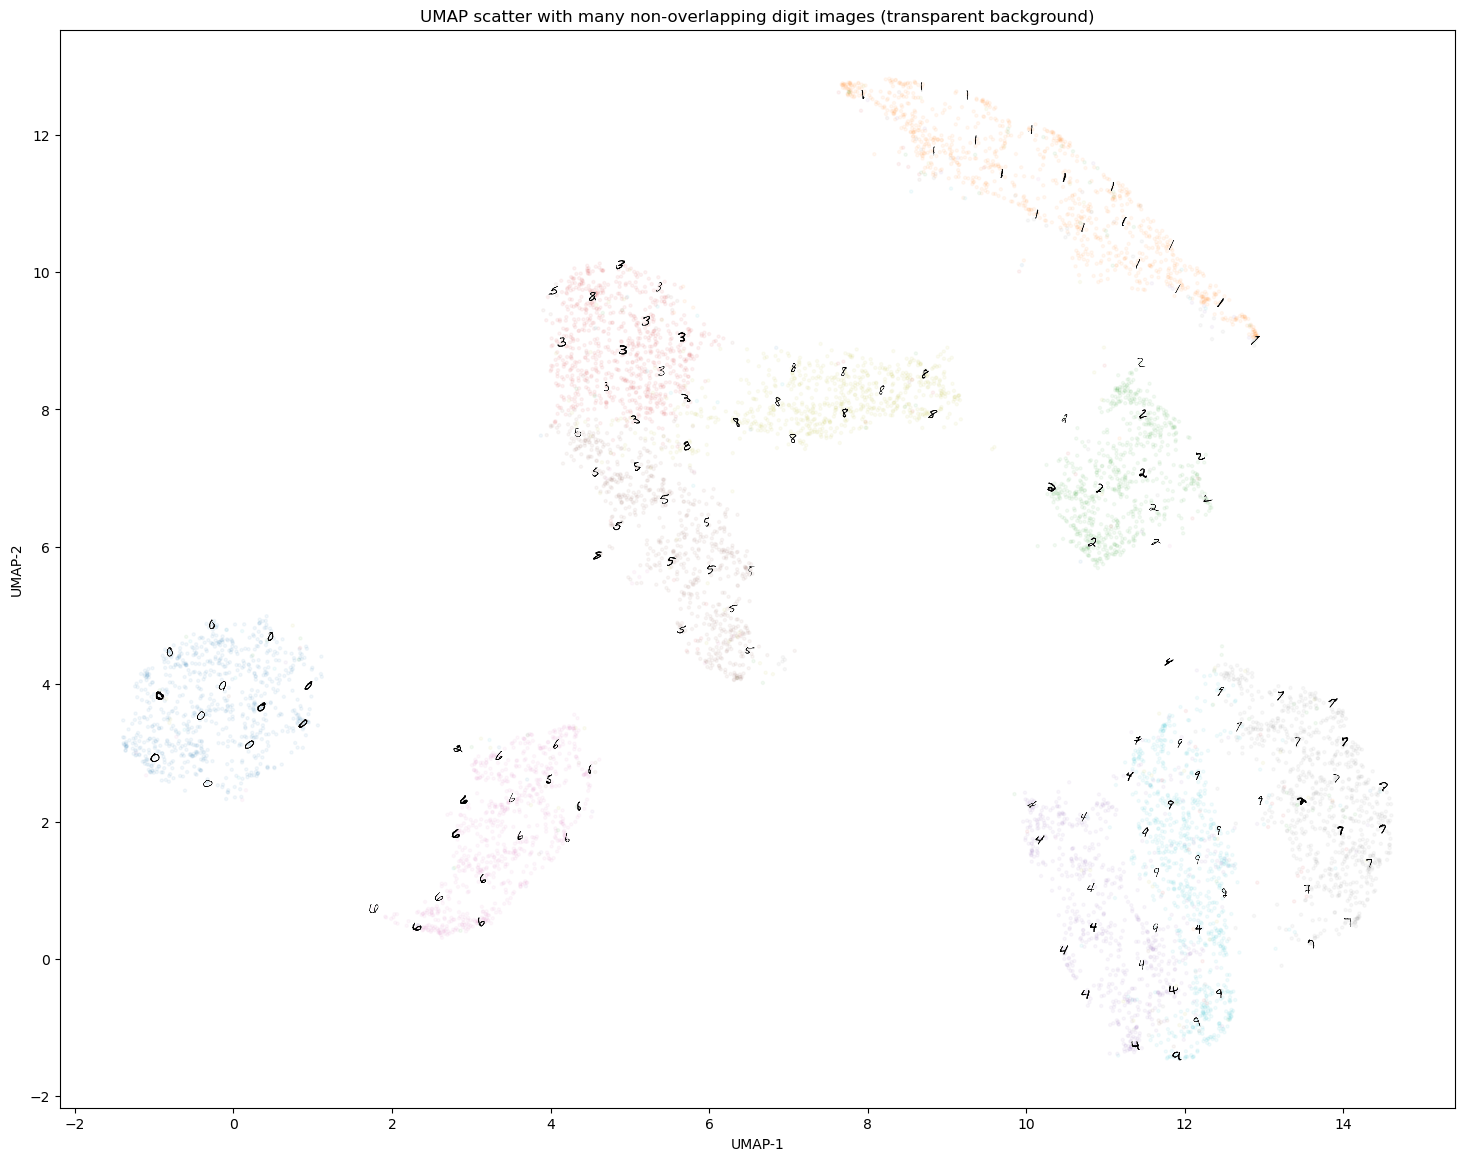

In [32]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

N_ATTEMPT = 1000  # Try to plot up to 1000 digits
MIN_DIST = 0.5    # Minimum UMAP distance between images to avoid overlap (tune as needed)
idx_attempt = np.random.choice(X_train.shape[0], N_ATTEMPT, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with many non-overlapping digit images (transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.05, cmap='tab10')

plotted = []
for i in idx_attempt:
    xy = Z_train[i]
    if plotted:
        dists = np.linalg.norm(np.array(plotted) - xy, axis=1)
        if np.any(dists < MIN_DIST):
            continue  # Skip if too close to any already plotted image
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img
    rgba_img[..., 1] = img
    rgba_img[..., 2] = img
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0/3.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)
    plotted.append(xy)

ax.update_datalim(np.array(plotted))
ax.autoscale_view()
plt.show()

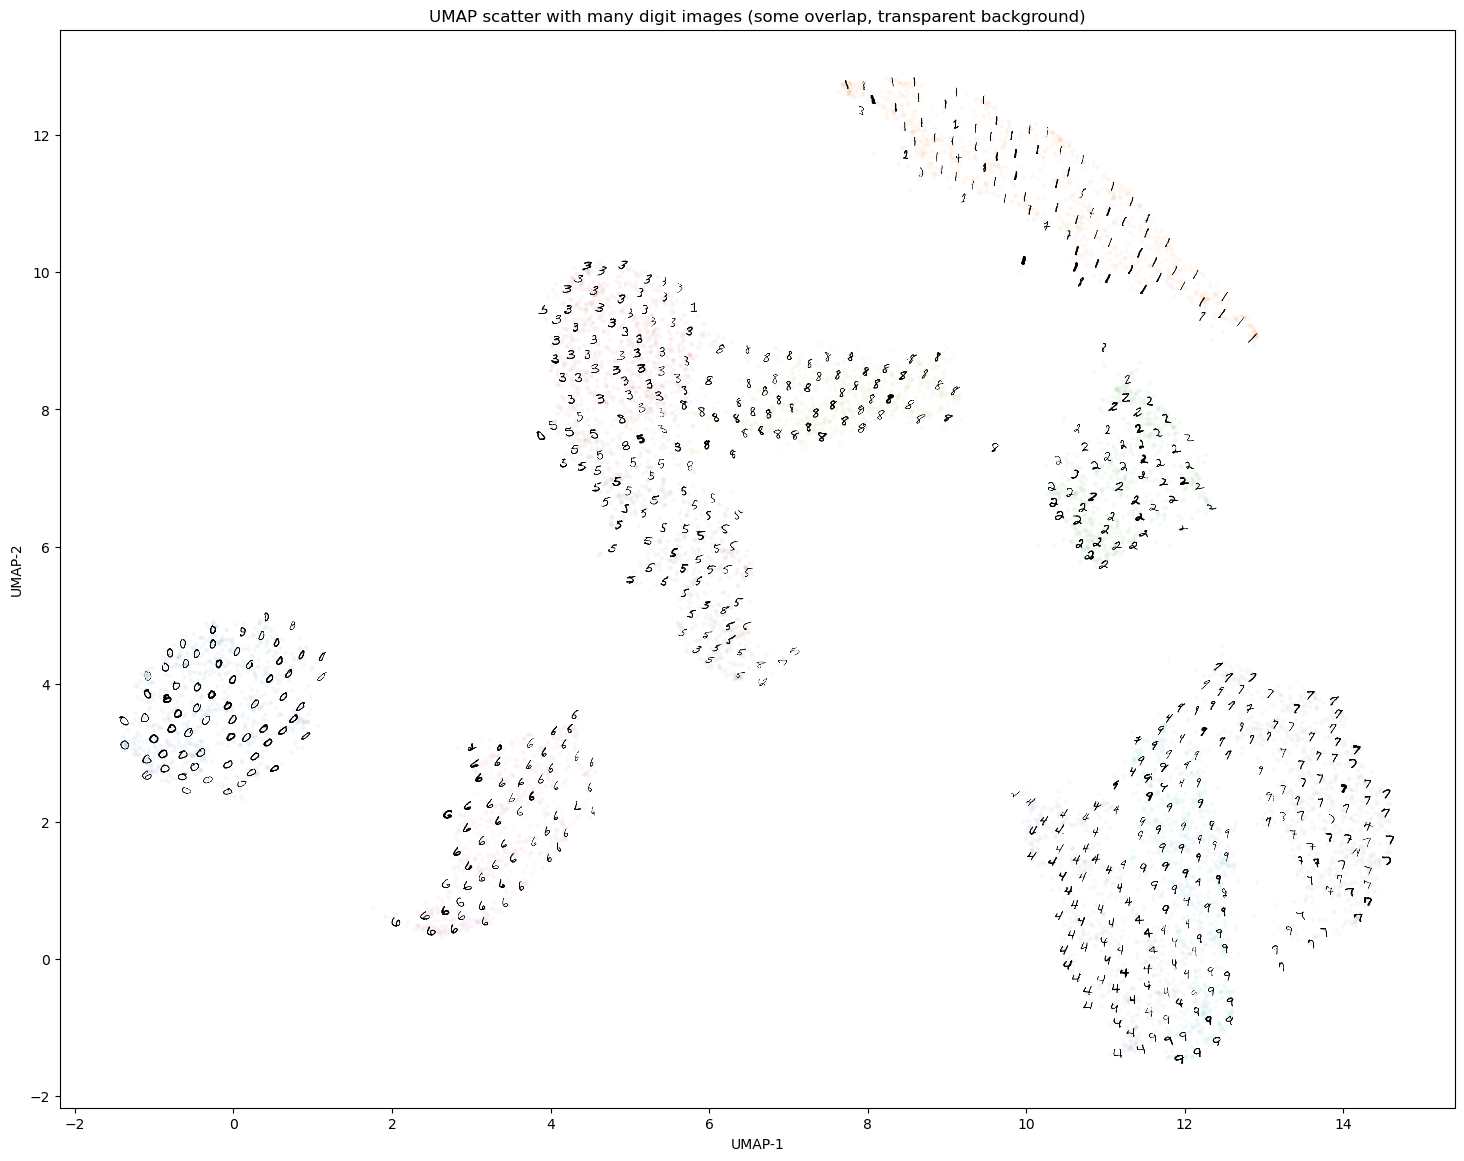

In [33]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

N_ATTEMPT = 4000  # Try to plot up to 4000 digits
MIN_DIST = 0.2    # Allow some overlap (smaller minimum distance)
idx_attempt = np.random.choice(X_train.shape[0], N_ATTEMPT, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with many digit images (some overlap, transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.03, cmap='tab10')

plotted = []
for i in idx_attempt:
    xy = Z_train[i]
    if plotted:
        dists = np.linalg.norm(np.array(plotted) - xy, axis=1)
        if np.any(dists < MIN_DIST):
            continue  # Skip if too close to any already plotted image
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img
    rgba_img[..., 1] = img
    rgba_img[..., 2] = img
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0/3.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)
    plotted.append(xy)

ax.update_datalim(np.array(plotted))
ax.autoscale_view()
plt.show()